### Importando as bibliotecas

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/despesas_ma_2025_tratado.csv", sep=";")

C:\Users\edils\AppData\Local\Temp\ipykernel_5268\3200093055.py:1: DtypeWarning: Columns (8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/despesas_ma_2025_tratado.csv", sep=";")


### Informações - Dataset

In [4]:
qtd_linhas, qtd_colunas = df.shape

print(f"O dataset possui total de {qtd_linhas} linhas e total de {qtd_colunas} colunas")

O dataset possui total de 1085608 linhas e total de 11 colunas


In [5]:
for colunas in df.columns:
    print(f"Coluna: {colunas}")

Coluna: ano
Coluna: mes
Coluna: fase
Coluna: codigo_unidade
Coluna: unidade
Coluna: valor
Coluna: codigo_credor
Coluna: credor_nome
Coluna: codigo_funcao
Coluna: codigo_natureza
Coluna: cod_grupo_despesa


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085608 entries, 0 to 1085607
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   ano                1085608 non-null  int64  
 1   mes                1085608 non-null  int64  
 2   fase               1085608 non-null  object 
 3   codigo_unidade     1085608 non-null  int64  
 4   unidade            1085608 non-null  object 
 5   valor              1085587 non-null  float64
 6   codigo_credor      1085608 non-null  object 
 7   credor_nome        1085608 non-null  object 
 8   codigo_funcao      1085595 non-null  object 
 9   codigo_natureza    1085608 non-null  object 
 10  cod_grupo_despesa  1085608 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 91.1+ MB


In [6]:
print(df['valor'].isna().sum())

21


In [7]:
df.describe()

,ano,mes,codigo_unidade,valor
count,1085608.0,1.085608e+06,1.085608e+06,1.085587e+06
mean,2025.0,7.363283e+00,2.583598e+05,5.178854e+06
std,0.0,3.265967e+00,1.479501e+05,1.058501e+08
min,2025.0,1.000000e+00,1.101030e+05,-5.358000e+09
25%,2025.0,5.000000e+00,1.701010e+05,6.000000e+03
50%,2025.0,8.000000e+00,2.109010e+05,1.660300e+04
75%,2025.0,1.000000e+01,2.402020e+05,7.800000e+04
max,2025.0,1.200000e+01,6.401010e+05,3.491304e+10


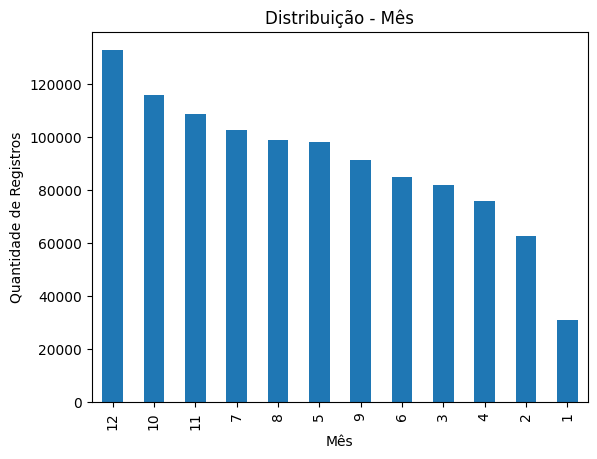

In [24]:
df['mes'].value_counts().plot(kind="bar")
plt.title("Distribuição - Mês")
plt.ylabel("Quantidade de Registros")
plt.xlabel("Mês")
plt.show()

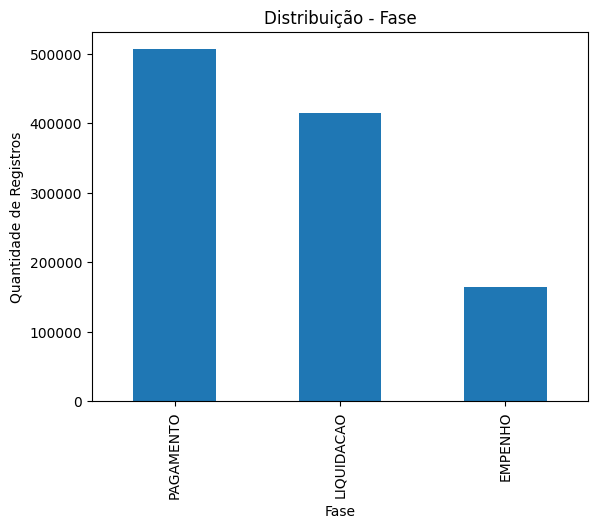

,Quantidade,Percentual (%)
fase,,
PAGAMENTO,506467,46.65
LIQUIDACAO,415161,38.24
EMPENHO,163980,15.10


In [22]:
plt.title("Distribuição - Fase")
df["fase"].value_counts().plot(kind="bar")
plt.ylabel("Quantidade de Registros")
plt.xlabel("Fase")

plt.show()


contagem = df['fase'].value_counts()
percentual = df['fase'].value_counts(normalize=True).mul(100).round(2)

df_resumo = pd.DataFrame({'Quantidade': contagem, 'Percentual (%)': percentual})
display(df_resumo)

In [25]:
df['credor_nome'].value_counts().head(20)

credor_nome
BOLSISTAS                                                                                     130997
PAGAMENTO DE BOLSA FORMAÃÃO DESTINADO A PAGTO DE PROFISSIONAIS CONF.DECRETO 33.844/2018.     80859
AUXÃLIO ALIMENTAÃÃO                                                                         26193
PROGRAMA TRABALHO JOVEM                                                                        19330
TRIBUNAL DE JUSTICA DO MARANHAO                                                                17418
FUNDO ESTADUAL DE PENSAO E APOSENTADORIA- FEPA                                                 16718
WHITE MARTINS GASES INDUSTRIAIS DO NORTE LTDA                                                  14371
PROGRAMA JUROS ZERO                                                                            13711
ALIMENTAÃÃO ESCOLAR MÃDIO CARTÃO PNAE FNDE                                                 13210
DIARIAS                                                                        

In [10]:
display(df["codigo_unidade"].value_counts().head(10))

codigo_unidade
170101    156217
240201    100476
170204     96307
240202     79513
210901     79511
240207     52648
540201     37243
560101     35280
150101     28502
110124     28324
Name: count, dtype: int64

In [11]:
valor_minimo = df["valor"].min()
valor_maximo = df["valor"].max()

print(f"A valor minimo: {valor_minimo} e valor máximo: {valor_maximo}")

A valor minimo: -5358000000.0 e valor máximo: 34913036878.0


#### Valores negativos

In [30]:
valor_negativo = df[df["valor"]<=0]
qtd_linhas_valor_negativo, qtd_colunas_valor_negativo = valor_negativo.shape

print(f"Total de linhas {qtd_linhas_valor_negativo}\nTotal de Colunas {qtd_colunas_valor_negativo}")

Total de linhas 20730
Total de Colunas 11


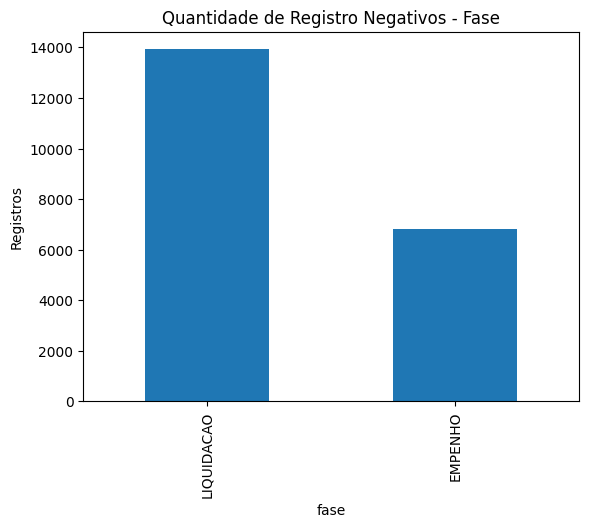

In [ ]:
plt.title("Quantidade de Registro Negativos - Fase")
plt.ylabel("Registros")
plt.xlabel("Fase")
plt.show(valor_negativo['fase'].value_counts().plot(kind="bar"))


In [35]:
valor_negativo_min = valor_negativo['valor'].min()
valor_negativo_max = valor_negativo['valor'].max()

print(f"Valor Negativo Minimo: {valor_negativo_min}\nValor Negativo Máximo: {valor_negativo_max}")

Valor Negativo Minimo: -5358000000.0
Valor Negativo Máximo: -1.0


In [46]:
valor_negativo[valor_negativo["valor"]<=-558000000].head(5).value_counts()

ano   mes  fase        codigo_unidade  unidade                                    valor          codigo_credor   credor_nome                                              codigo_funcao  codigo_natureza  cod_grupo_despesa
2025  1    EMPENHO     170101          Secretaria de Estado da EducaÃ§Ã£o         -2.833952e+09  00000PF0000096  SEC. EDUCAÃÃO (FOLHA EFETIVO FUNDEB ENS. FUNDAMENTAL)  12.0           331901101        3                    1
                                                                                  -7.789458e+08  00000PF0000101  SEC. EDUCAÃÃO (FOLHA DO5 ENSINO MÃDIO)                12.0           331901302        3                    1
      3    EMPENHO     160101          Secretaria de Estado da Fazenda            -9.928593e+08  03526252000147  SECRETARIA DE ESTADO DA FAZENDA                          4              331901101        3                    1
                       530101          Secretaria de Estado da Infraestrutura     -5.587326e+08  08634231

In [43]:
valor_negativo[valor_negativo["valor"]>=-1].head(5)

,ano,mes,fase,codigo_unidade,unidade,valor,codigo_credor,credor_nome,codigo_funcao,codigo_natureza,cod_grupo_despesa
1163,2025,1,EMPENHO,110121,Secretaria de Estado da ComunicaÃ§Ã£o Social,-1.0,13441026000117,J.J.REFRIGERACOES E INSTALACOES ELETRICA LTDA,4.0,333903999,3
33292,2025,2,EMPENHO,110121,Secretaria de Estado da ComunicaÃ§Ã£o Social,-1.0,54696579000106,H R D COMERCIO E SERVICOS LTDA,4.0,333904002,3
96415,2025,3,EMPENHO,110121,Secretaria de Estado da ComunicaÃ§Ã£o Social,-1.0,05060367000114,TECHNOCOPY EQUIP. SUPRIMENTOS E SERVICOS LTDA,4,333909239,3
99556,2025,3,EMPENHO,120208,AgÃªncia Executiva Metropolitana do Sudoeste d,-1.0,11302593000167,PALMARES CONSTRUCOES LTDA,15,344905107,4
99558,2025,3,EMPENHO,120208,AgÃªncia Executiva Metropolitana do Sudoeste d,-1.0,11302593000167,PALMARES CONSTRUCOES LTDA,15,344905107,4


#### Valores Positivos

In [49]:
valor_positivo = df[df["valor"]>0]
qtd_linhas_valor_positivo, qtd_colunas_valor_positivo = valor_positivo.shape
print(f"Quantidade de linhas: {qtd_linhas_valor_positivo}\nQuantidade de colunas: {qtd_colunas_valor_positivo}")

Quantidade de linhas: 1064857
Quantidade de colunas: 11


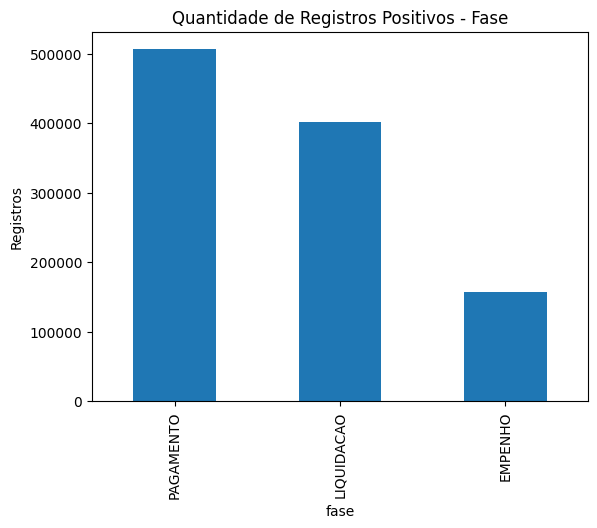

In [55]:
plt.title("Quantidade de Registros Positivos - Fase")
plt.ylabel("Registros")
plt.xlabel("fase")

plt.show(valor_positivo["fase"].value_counts().plot(kind="bar"))

##### Fase - Pagamento

In [70]:
valor_positivo_pagamento = valor_positivo[valor_positivo["fase"]=="PAGAMENTO"]

valor_positivo_pagamento_maior_0 =valor_positivo_pagamento[valor_positivo_pagamento["valor"]>0]

#display(valor_positivo_pagamento_maior_0.head(2))

qtd_linhas_valor_positivo_pagamento_maior_0, qtd_colunas_valor_positivo_pagamento_maior_0 = valor_positivo_pagamento_maior_0.shape
print(f"Quantidade de linhas: {qtd_linhas_valor_positivo_pagamento_maior_0}\nQuantidade de colunas: {qtd_colunas_valor_positivo_pagamento_maior_0}")

Quantidade de linhas: 506460
Quantidade de colunas: 11


In [77]:
display(valor_positivo_pagamento_maior_0[valor_positivo_pagamento_maior_0["valor"]<=0])

,ano,mes,fase,codigo_unidade,unidade,valor,codigo_credor,credor_nome,codigo_funcao,codigo_natureza,cod_grupo_despesa


In [78]:
valor_positivo_pagamento_maior_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506460 entries, 0 to 1085607
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ano                506460 non-null  int64  
 1   mes                506460 non-null  int64  
 2   fase               506460 non-null  object 
 3   codigo_unidade     506460 non-null  int64  
 4   unidade            506460 non-null  object 
 5   valor              506460 non-null  float64
 6   codigo_credor      506460 non-null  object 
 7   credor_nome        506460 non-null  object 
 8   codigo_funcao      506452 non-null  object 
 9   codigo_natureza    506460 non-null  object 
 10  cod_grupo_despesa  506460 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 46.4+ MB


In [82]:
valor_positivo_pagamento_maior_0.to_csv("Despesas_MA_2025_pagamentos.csv",index=False)